# Jaguar Re-Identification Baseline with MegaDescriptor and ArcFace

# TODO

This notebook demonstrates a complete pipeline for training a jaguar re-identification model using MegaDescriptor embeddings and ArcFace loss. The goal is to learn embeddings that place images of the same jaguar close together and images of different jaguars far apart.

## Overview

1. **Data Loading**: Load training images and create a stratified train/validation split
2. **MegaDescriptor**: Extract baseline embeddings using a pre-trained vision transformer
3. **Visualization**: Use MDS to visualize embeddings before and after fine-tuning
4. **ArcFace Training**: Fine-tune embeddings using angular margin loss
5. **Submission**: Generate predictions for the competition test set

## Key Concepts

**MegaDescriptor** is a vision transformer trained on wildlife re-identification datasets. It produces 1536-dimensional embeddings that capture visual features useful for distinguishing individual animals.

**ArcFace (Additive Angular Margin Loss)** is a metric learning technique that:
- Projects embeddings onto a unit hypersphere (L2 normalized)
- Optimizes angular distances between class centers
- Adds an angular margin to improve class separation

The combination allows us to fine-tune MegaDescriptor for our specific jaguar dataset.

## 1. Setup and Configuration

In [ ]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from torchvision.ops import sigmoid_focal_loss
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_similarity
import math
import wandb
from dotenv import load_dotenv


ON_KAGGLE = 'KAGGLE_URL_BASE' in os.environ
# Load environment variables from .env file
# The .env file should contain: WANDB_API_KEY, WANDB_PROJECT, HF_TOKEN
env_path = Path(".env")
if env_path.exists():
    load_dotenv(env_path)
    print(f"Loaded environment variables from {env_path}")
else:
    print(f"Warning: {env_path} not found. Set WANDB_API_KEY and HF_TOKEN manually.")

if (ON_KAGGLE):
    try:
        from kaggle_secrets import UserSecretsClient
        user_secrets = UserSecretsClient()
        os.environ["HF_TOKEN"]= user_secrets.get_secret("hf_api")
        os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")
    except ImportError:
        print("Kaggle secrets not available. Make sure to set environment variables for HF_TOKEN and WANDB_API_KEY.")


print(f"PyTorch version: {torch.__version__}")
print(f"timm version: {timm.__version__}")

Loaded environment variables from ../.env
PyTorch version: 2.10.0+cu128
timm version: 1.0.25


In [2]:
# Device configuration
# MPS (Metal Performance Shaders) provides GPU acceleration on Apple Silicon (if you want to run this notebook locally on your MacBook)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")
    #raise RuntimeError("No GPU available. Please run this notebook on a machine with CUDA or MPS support for better performance.")

print(f"Device: {device}")

Using CPU
Device: cpu


In [ ]:
# Configuration
run_config_path = os.getenv("RUN_CONFIG_PATH", "configs/baseline.json")
config_path = Path(run_config_path).expanduser()

if not config_path.is_absolute():
    config_path = (Path.cwd() / config_path).resolve()

if not config_path.exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

with config_path.open("r", encoding="utf-8") as f:
    config = json.load(f)
    
# update kaggle paths
if ON_KAGGLE:
    config["data_dir"] = "/kaggle/input/jaguar-reid-dataset"

# Convert path-like fields loaded from JSON to Path objects for downstream code
for path_key in ("data_dir", "checkpoint_dir"):
    if path_key in config:
        config[path_key] = Path(config[path_key])

# Keep reproducibility aligned with loaded configuration
if "seed" in config:
    RANDOM_SEED = int(config["seed"])
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

# Create checkpoint directory
config["checkpoint_dir"].mkdir(parents=True, exist_ok=True)

print(f"Loaded configuration from: {config_path}")
print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Loaded configuration from: /sc/home/linus.loell/jaguar-reid-linus-loell/configs/baseline.json
Configuration:
  run_name: lr-scheduler
  data_dir: ../data
  checkpoint_dir: checkpoints
  model: hf-hub:BVRA/MegaDescriptor-L-384
  input_size: 384
  embedding_dim: 256
  hidden_dim: 512
  loss_type: arcface
  focal_alpha: 0.25
  focal_gamma: 2.0
  focal_reduction: mean
  arcface_margin: 0.5
  arcface_scale: 64.0
  sphere_m: 4
  sphere_scale: 64.0
  dropout: 0.3
  batch_size: 32
  learning_rate: 0.0001
  lr_scheduler_type: cosine
  weight_decay: 0.0001
  num_epochs: 50
  patience: 10
  val_split: 0.2
  seed: 42


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
wandb.finish()  # Finish any previous runs to avoid conflicts

wandb_api_key = os.getenv("WANDB_API_KEY")
if wandb_api_key:
    wandb.login()
else:
    raise EnvironmentError(
        "WANDB_API_KEY not set. Make sure your .env file exists at the repo root "
        "and contains: WANDB_API_KEY=your_key_here"
    )

wandb.init(
    project=os.getenv("WANDB_PROJECT", "jaguar-reid-linus-loell"),
    config={
        # Model architecture
        "model": config["model"],
        "embedding_dim": config["embedding_dim"],
        "hidden_dim": config["hidden_dim"],
        "dropout": config["dropout"],
        "loss_type": config["loss_type"],
        
        # Focal hyperparameters
        "focal_alpha": config["focal_alpha"],
        "focal_gamma": config["focal_gamma"],
        "focal_reduction": config["focal_reduction"],
        
        # ArcFace hyperparameters (critical for performance)
        "arcface_margin": config["arcface_margin"],
        "arcface_scale": config["arcface_scale"],
        
        # SphereFace hyperparameters
        "sphere_m": config["sphere_m"],
        "sphere_scale": config["sphere_scale"],
        
        # Training hyperparameters
        "batch_size": config["batch_size"],
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "num_epochs": config["num_epochs"],
        "patience": config["patience"],
        "val_split": config["val_split"],
        "seed": config["seed"],
    },
    reinit=True,
    name=config["run_name"],
)

print("W&B initialized. Key hyperparameters tracked:")
print(f"  Project: {os.getenv('WANDB_PROJECT', 'jaguar-reid-linus-loell')}")
print(f"  ArcFace margin: {config['arcface_margin']} ({config['arcface_margin'] * 180 / 3.14159:.1f}°)")
print(f"  ArcFace scale: {config['arcface_scale']}")
print(f"  SphereFace m: {config['sphere_m']}")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Dropout: {config['dropout']}")
print(f"  Loss type: {config['loss_type']}")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: Currently logged in as: linus-loell to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


W&B initialized. Key hyperparameters tracked:
  Project: jaguar-reid-linus-loell
  ArcFace margin: 0.5 (28.6°)
  ArcFace scale: 64.0
  SphereFace m: 4
  Embedding dim: 256
  Dropout: 0.3
  Loss type: arcface


In [5]:
print("WandB run started with name:", wandb.run.name)

WandB run started with name: lr-scheduler


## 2. Load and Prepare Data

We load the training data from `train.csv` which contains image filenames and their corresponding jaguar identity labels. The key challenge is creating a proper train/validation split:

**Stratified Split**: We ensure every jaguar identity appears in both the training and validation sets. This is critical because:
1. The model must learn to recognize all individuals during training
2. Validation mAP should reflect performance across all identities
3. Identities with few images still need representation in both sets

In [1]:
from utils import load_train_data, plot_identity_distribution, create_train_val_split

# Load training data
train_df = load_train_data(config["data_dir"], seed=config["seed"])

NameError: name 'config' is not defined

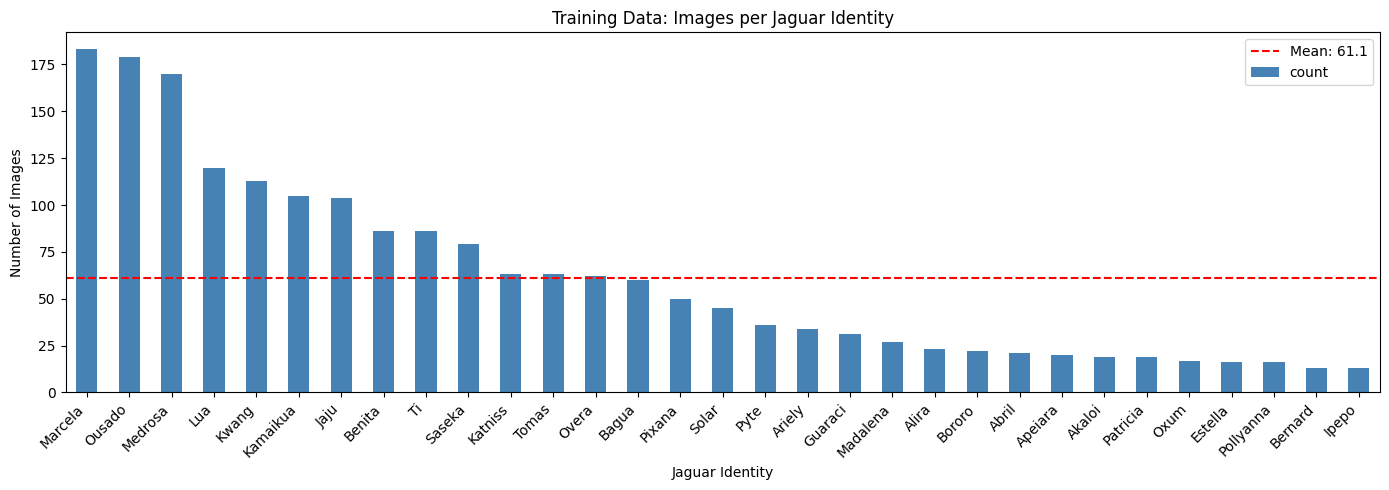

In [7]:
# Visualize identity distribution and log to W&B
plot_identity_distribution(train_df, log_wandb=True)

Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  ✓ All identities present in both sets


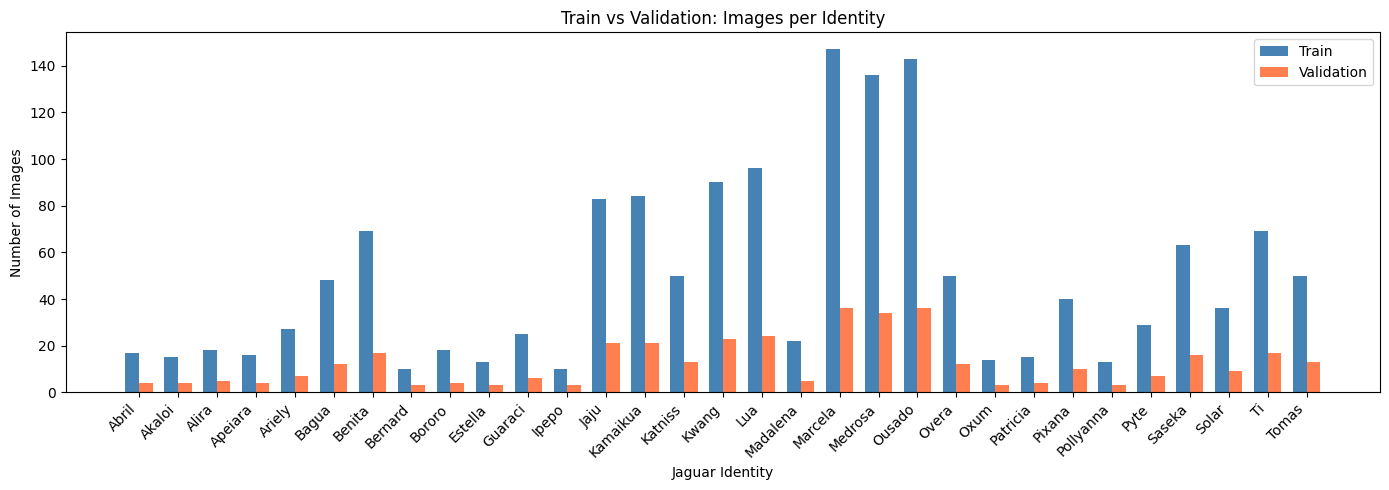


Logged identity distributions to W&B
  Train samples per identity: 10 – 147 (mean: 48.9)
  Val samples per identity:   3 – 36 (mean: 12.2)


In [8]:
# Create stratified train/validation split
train_data, val_data, label_encoder, num_classes = create_train_val_split(
    train_df,
    val_split=config["val_split"],
    seed=config["seed"],
    log_wandb=True,
)

In [9]:
# TODO: remove later
# for debugging reduce dataset size on cpu
if (not torch.cuda.is_available()):
    fraction = 0.01
    train_data = train_data.sample(frac=fraction, random_state=config["seed"])
    val_data = val_data.sample(frac=fraction, random_state=config["seed"])

## 3. Load Backbone Model

In [10]:
# Load MegaDescriptor model
print("Loading MegaDescriptor-L-384 model...")
backbone = timm.create_model(
    config["model"],
    pretrained=True
)
backbone.eval()
backbone.to(device)

print(f"Model loaded successfully")
backbone_params = sum(p.numel() for p in backbone.parameters())
print(f"  Parameters: {backbone_params:,}")
wandb.config.update({"backbone_parameters": backbone_params}, allow_val_change=True)
    

Loading MegaDescriptor-L-384 model...
Model loaded successfully
  Parameters: 195,198,516


In [11]:
# Get the embedding dimension from the model
with torch.no_grad():
    dummy_input = torch.randn(1, 3, config["input_size"], config["input_size"]).to(device)
    dummy_output = backbone(dummy_input)
    
    backbone_dim = dummy_output.shape[1]     
    
    print(f"  Final embedding dimension: {backbone_dim}")
    wandb.config.update({"backbone_embedding_dim": backbone_dim}, allow_val_change=True)


  Final embedding dimension: 1536


In [12]:
# Define preprocessing pipeline
# MegaDescriptor expects 384x384 images normalized with ImageNet statistics
preprocess = transforms.Compose([
    transforms.Resize((config["input_size"], config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

print("Preprocessing pipeline configured:")
print(f"  Resize to: {config['input_size']}x{config['input_size']}")
print(f"  Normalization: ImageNet statistics")

Preprocessing pipeline configured:
  Resize to: 384x384
  Normalization: ImageNet statistics


In [13]:
@torch.no_grad()
def extract_embeddings(model, image_paths, batch_size=32, desc="Extracting embeddings"):
    """Extract embeddings for a list of image paths using the backbone model."""
    model.eval()
    embeddings = []
    
    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[i:i + batch_size]
        
        # Load and preprocess batch
        batch_tensors = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                tensor = preprocess(img)
                batch_tensors.append(tensor)
            except Exception as e:
                print(f"Error loading {path}: {e}")
                # Use zero tensor as fallback
                batch_tensors.append(torch.zeros(3, config["input_size"], config["input_size"]))
        
        # Stack and move to device
        batch_tensor = torch.stack(batch_tensors).to(device)
        
        # Get embeddings from model
        batch_emb = model(batch_tensor).cpu().numpy()
        embeddings.append(batch_emb)
            
    return np.vstack(embeddings)

print("Embedding extraction function defined")

Embedding extraction function defined


In [ ]:
emb_dir = Path("/kaggle/working/embeddings") if ON_KAGGLE else Path("embeddings")

# Create subfolder for model-specific embeddings
model_name_safe = config["model"].replace("/", "_")
model_emb_dir = emb_dir / model_name_safe
model_emb_dir.mkdir(parents=True, exist_ok=True)

cache_path = model_emb_dir / "baseline_train_embeddings.npz"

# Extract baseline embeddings for training data
train_filenames = train_data["filename"].astype(str).tolist()
train_image_paths = [config["data_dir"] / "train/train" / fn for fn in train_filenames]

def _load_cached_embeddings(cache_path, expected_filenames):
    z = np.load(cache_path, allow_pickle=True)
    cached_embeddings = z["embeddings"]
    cached_filenames = z["filenames"].tolist() if isinstance(z["filenames"], np.ndarray) else list(z["filenames"])

    # Reject cache if embeddings are not 2D
    if cached_embeddings.ndim != 2:
        print(f"Cache has unexpected shape {cached_embeddings.shape}, discarding.")
        return None

    if len(cached_filenames) != len(expected_filenames):
        return None

    if set(cached_filenames) != set(expected_filenames):
        return None

    if cached_filenames == expected_filenames:
        return cached_embeddings

    idx = {fn: i for i, fn in enumerate(cached_filenames)}
    return np.stack([cached_embeddings[idx[fn]] for fn in expected_filenames], axis=0)

print(f"Storing embeddings in: {model_emb_dir}")

baseline_train_embeddings = None
if cache_path.exists():
    baseline_train_embeddings = _load_cached_embeddings(cache_path, train_filenames)
    if baseline_train_embeddings is not None:
        print(f"Loaded cached baseline embeddings from {cache_path}")
        print(f"Baseline embeddings shape: {baseline_train_embeddings.shape}")

if baseline_train_embeddings is None:
    print(f"Extracting baseline embeddings for {len(train_image_paths)} training images...")
    baseline_train_embeddings = extract_embeddings(
        backbone,
        train_image_paths,
        batch_size=config["batch_size"]
    )
    np.savez_compressed(
        cache_path,
        embeddings=baseline_train_embeddings,
        filenames=np.array(train_filenames, dtype=object),
    )
    print(f"Saved baseline embeddings cache to {cache_path}")
    print(f"Baseline embeddings shape: {baseline_train_embeddings.shape}")


Storing embeddings in: ../embeddings/hf-hub:BVRA_MegaDescriptor-L-384
Extracting baseline embeddings for 15 training images...


Extracting embeddings:   0%|          | 0/1 [00:00<?, ?it/s]

Saved baseline embeddings cache to ../embeddings/hf-hub:BVRA_MegaDescriptor-L-384/baseline_train_embeddings.npz
Baseline embeddings shape: (15, 1536)


## 4. Visualize Baseline Embeddings with MDS

Multidimensional Scaling (MDS) projects high-dimensional embeddings to 2D while preserving pairwise distances. For embeddings on a hypersphere (L2-normalized), we use geodesic distances (arc length) rather than Euclidean distances.

This visualization shows how well the backbone model separates different jaguars before any fine-tuning.

In [15]:
def compute_geodesic_distances(embeddings):
    """Compute geodesic (angular) distance matrix for normalized embeddings."""
    # Normalize embeddings to unit sphere
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normalized = embeddings / norms
    
    # Compute cosine similarity
    cos_sim = np.clip(normalized @ normalized.T, -1.0, 1.0)
    
    # Convert to geodesic distance (arc length)
    geodesic_dist = np.arccos(cos_sim)
    
    return geodesic_dist


def visualize_embeddings_mds(embeddings, labels, title, max_samples=500):
    """Visualize embeddings using MDS with geodesic distances."""
    # Subsample if too many points (MDS is O(n^3))
    if len(embeddings) > max_samples:
        indices = np.random.choice(len(embeddings), max_samples, replace=False)
        embeddings = embeddings[indices]
        labels = labels[indices]
    
    # Compute geodesic distance matrix
    dist_matrix = compute_geodesic_distances(embeddings)
    
    # Apply MDS
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=RANDOM_SEED, normalized_stress='auto')
    coords_2d = mds.fit_transform(dist_matrix)
    
    # Create color mapping for identities
    unique_labels = np.unique(labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    for label in unique_labels:
        mask = labels == label
        ax.scatter(
            coords_2d[mask, 0], 
            coords_2d[mask, 1],
            c=[label_to_color[label]],
            label=label,
            alpha=0.7,
            s=30
        )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('MDS Dimension 1')
    ax.set_ylabel('MDS Dimension 2')
    
    # Legend outside plot
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    
    return fig

print("MDS visualization functions defined")

MDS visualization functions defined


/sc/home/linus.loell/jaguar-reid-linus-loell/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/linus.loell/jaguar-reid-linus-loell/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/linus.loell/jaguar-reid-linus-loell/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


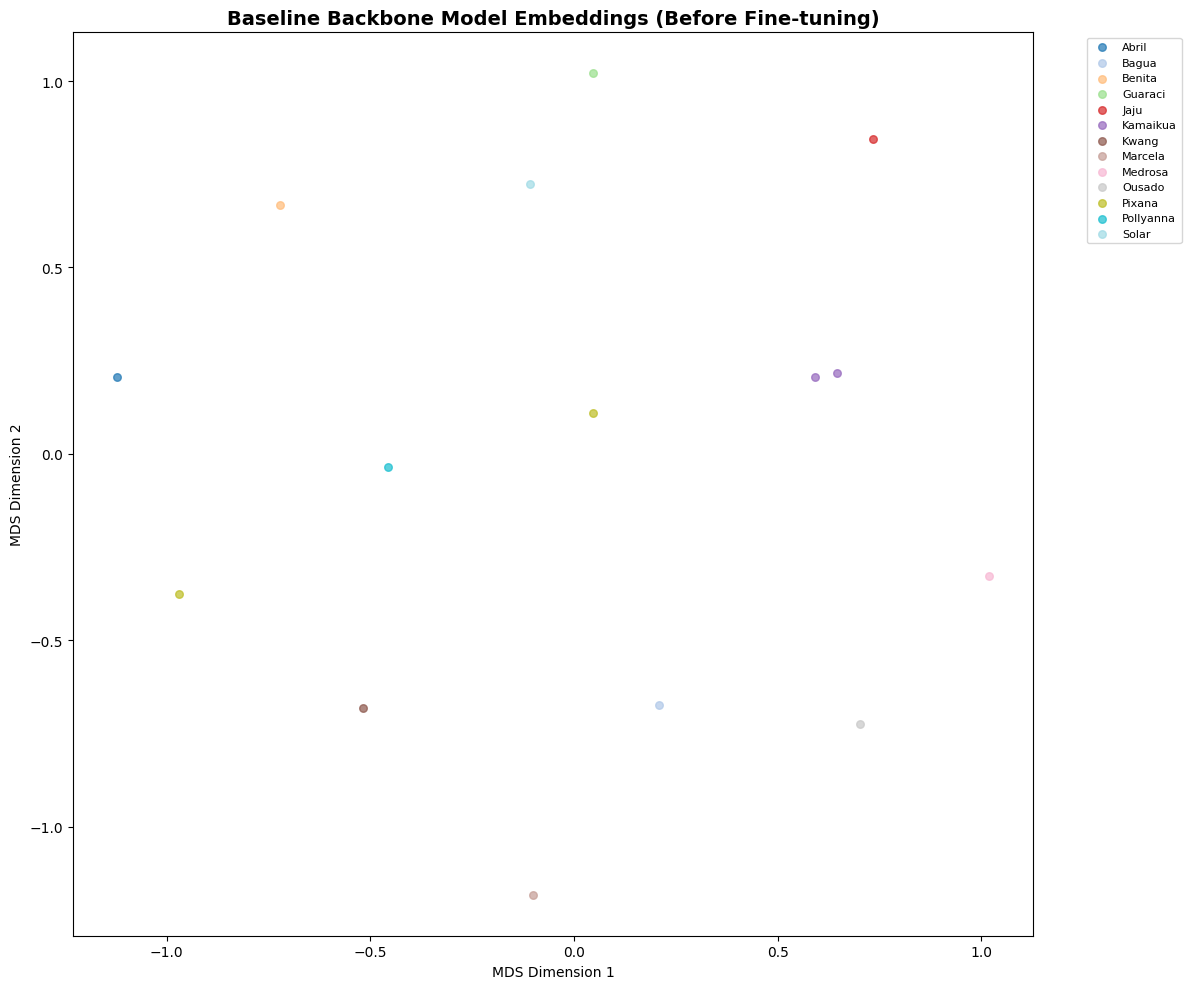

In [16]:
# Visualize baseline embeddings
train_labels = train_data['ground_truth'].values

fig_baseline = visualize_embeddings_mds(
    baseline_train_embeddings,
    train_labels,
    "Baseline Backbone Model Embeddings (Before Fine-tuning)"
)
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig_baseline)})

## 5. Define Model Architecture

We define two components:

1. **EmbeddingProjection**: Projects 768-dim ConvNextV2 embeddings to a lower-dimensional space (configured via `embedding_dim`, default 768). This learned projection optimizes the embedding space for our specific jaguar dataset.

2. **ArcFaceLayer**: Implements Additive Angular Margin Loss. It:
   - Normalizes embeddings to unit length (projects to hypersphere)
   - Computes cosine similarity to class weight vectors
   - Adds angular margin to the ground truth class before softmax
   - Scales logits to sharpen the distribution

In [17]:
class EmbeddingProjection(nn.Module):
    """
    Projects Backbone embeddings to a lower-dimensional space.
    Architecture: input_dim -> hidden_dim -> output_dim
    """
    
    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.network(x)


class ArcFaceLayer(nn.Module):
    """
    ArcFace (Additive Angular Margin Loss) layer.
    
    The loss is computed as:
        L = -log(exp(s * cos(theta_y + m)) / (exp(s * cos(theta_y + m)) + sum(exp(s * cos(theta_j)))))
    
    where:
        - theta_y is the angle between embedding and ground truth class center
        - m is the angular margin (default 0.5 radians, about 28.6 degrees)
        - s is the feature scale (default 64)
    """
    
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        
        # Learnable weight matrix (class prototypes on the hypersphere)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        
        # Pre-compute trigonometric values for efficiency
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)  # Threshold for numerical stability
        self.mm = math.sin(math.pi - margin) * margin
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (batch_size, embedding_dim) - will be normalized
            labels: (batch_size,) - ground truth class indices
        
        Returns:
            logits: (batch_size, num_classes) - ArcFace logits for cross-entropy loss
        """
        # Normalize embeddings and weights to unit length
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # Compute cosine similarity: cos(theta)
        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)
        
        # Compute sin(theta) from cos(theta)
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        
        # Compute cos(theta + m) using angle addition formula
        # cos(theta + m) = cos(theta)*cos(m) - sin(theta)*sin(m)
        phi = cosine * self.cos_m - sine * self.sin_m
        
        # Apply threshold to handle theta + m >= pi
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        # One-hot encode labels
        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        
        # Apply margin only to ground truth class
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        # Scale logits
        output = output * self.scale
        
        return output


class SphereFaceLayer(nn.Module):
    """
    SphereFace (Angular Softmax Loss) layer.
    
    Uses the formulation: cos(m * theta) where m is an integer multiplier.
    This creates a stricter angular margin than ArcFace through angle multiplication.
    
    The loss is computed as:
        L = -log(exp(s * cos(m*theta_y)) / (exp(s * cos(m*theta_y)) + sum(exp(s * cos(theta_j)))))
    
    where:
        - theta_y is the angle to the ground truth class
        - m is an integer multiplier (typically 1-4, default 4)
        - s is the feature scale (default 64)
    """
    
    def __init__(self, embedding_dim, num_classes, m=4, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.m = m  # Integer multiplier
        self.scale = scale
        
        # Learnable class prototypes on the hypersphere
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (batch_size, embedding_dim) - will be normalized
            labels: (batch_size,) - ground truth class indices
        
        Returns:
            logits: (batch_size, num_classes) - SphereFace logits for cross-entropy loss
        """
        # Normalize to unit sphere
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        
        # Compute cosine: cos(theta)
        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)
        
        # Compute theta from cosine
        theta = torch.acos(cosine)
        
        # Apply multiplier: theta -> m*theta, then take cosine
        phi = torch.cos(self.m * theta)
        
        # One-hot encode labels
        one_hot = F.one_hot(labels, num_classes=self.num_classes).float()
        
        # Apply margin only to ground truth class
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        # Scale
        output = output * self.scale
        
        return output


print("EmbeddingProjection, ArcFaceLayer, and SphereFaceLayer defined")

EmbeddingProjection, ArcFaceLayer, and SphereFaceLayer defined


In [18]:
# Adaptable Model Wrapper
# Supports different loss functions with a unified interface

class ClassificationModel(nn.Module):
    """
    model architecture that supports multiple loss functions.
    
    Components:
    1. EmbeddingProjection: Always present, projects backbone embeddings to lower dim
    2. Loss Head: Varies by loss_type
    """
    
    def __init__(self, input_dim, num_classes, loss_type, embedding_dim=256, hidden_dim=512, dropout=0.3, **loss_kwargs):
        super().__init__()
        
        self.loss_type = loss_type
        self.num_classes = num_classes
        self.embedding_dim = embedding_dim
        
        # Shared embedding projection layer
        self.embedding_net = EmbeddingProjection(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            output_dim=embedding_dim,
            dropout=dropout
        )
        
        # Loss-specific head
        if loss_type == "arcface":
            # ArcFace head
            self.loss_head = ArcFaceLayer(
                embedding_dim=embedding_dim,
                num_classes=num_classes,
                margin=loss_kwargs.get("margin", 0.5),
                scale=loss_kwargs.get("arcface_scale", 64.0),
            )
        elif loss_type in ["ce", "focal"]:
            # Linear classifier head
            self.loss_head = nn.Linear(embedding_dim, num_classes)
        elif loss_type == "sphere":
            # SphereFace head
            self.loss_head = SphereFaceLayer(
                embedding_dim=embedding_dim,
                num_classes=num_classes,
                m=loss_kwargs.get("m", 4),
                scale=loss_kwargs.get("sphere_scale", 64.0),
            )
        else:
            raise ValueError(f"Unsupported loss_type: {loss_type}")
    
    def forward(self, x, labels=None):
        """
        Forward pass
        
        Args:
            x: Input embeddings (batch_size, input_dim)
            labels: Class labels (batch_size,) - required for some losses, ignored for others
            
        Returns:
            Tuple of (output, embeddings) where:
            - output: logits for CE/Focal losses, or marginalized logits for ArcFace/SphereFace
            - embeddings: raw embeddings from projection head
        """
        embeddings = self.embedding_net(x)

        if self.loss_type in ["arcface", "sphere"]:
            if labels is None:
                raise ValueError(f"{self.loss_type.capitalize()} loss requires labels")
            logits = self.loss_head(embeddings, labels)
        elif self.loss_type in ["ce", "focal"]:
            logits = self.loss_head(embeddings)
        else:
            raise ValueError(f"Unsupported loss_type in forward: {self.loss_type}")

        return logits, embeddings
    
    def get_embeddings(self, x, normalize=True):
        """Get embeddings for inference."""
        embeddings = self.embedding_net(x)
        if normalize:
            embeddings = F.normalize(embeddings, p=2, dim=1)
        return embeddings

In [19]:
# Create adaptable model based on selected loss type
model = ClassificationModel(
    input_dim=backbone_dim,
    num_classes=num_classes,
    loss_type=config["loss_type"],
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    dropout=config["dropout"],
    # Loss-specific kwargs
    margin=config.get("arcface_margin", 0.5),
    arcface_scale=config.get("arcface_scale", 64.0),
    sphere_scale=config.get("sphere_scale", 64.0),
    m=config.get("sphere_m", 4),
).to(device)

print(f"Model created with {config['loss_type'].upper()} loss:")
print(f"  Input dim: {backbone_dim}")
print(f"  Hidden dim: {config['hidden_dim']}")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Dropout: {config['dropout']}")
print(f"  Num classes: {num_classes}")
print(f"  Loss type: {config['loss_type']}")

if config["loss_type"] == "arcface":
    print(f"  ArcFace margin: {config['arcface_margin']}")
    print(f"  ArcFace scale: {config['arcface_scale']}")

if config["loss_type"] == "sphere":
    print(f"  SphereFace m: {config['sphere_m']}")
    print(f"  SphereFace scale: {config['sphere_scale']}")

classifier_params = sum(p.numel() for p in model.parameters())
print(f"  Total parameters: {classifier_params:,}")

wandb.config.update({"classifier_parameters": classifier_params}, allow_val_change=True)
wandb.config.update({"total_parameters": backbone_params + classifier_params}, allow_val_change=True)

Model created with ARCFACE loss:
  Input dim: 1536
  Hidden dim: 512
  Embedding dim: 256
  Dropout: 0.3
  Num classes: 31
  Loss type: arcface
  ArcFace margin: 0.5
  ArcFace scale: 64.0
  Total parameters: 927,744


## 6. Prepare DataLoaders

We create PyTorch datasets from the pre-computed Backbone embeddings. This is more efficient than loading images during training since embedding extraction is the bottleneck.

In [20]:
# Extract embeddings for validation set
val_image_paths = [
    config["data_dir"] / "train/train" / filename 
    for filename in val_data['filename'].values
]

print(f"Extracting embeddings for {len(val_image_paths)} validation images...")
baseline_val_embeddings = extract_embeddings(
    backbone, 
    val_image_paths, 
    batch_size=config["batch_size"]
)

print(f"Validation embeddings shape: {baseline_val_embeddings.shape}")

Extracting embeddings for 4 validation images...


Extracting embeddings:   0%|          | 0/1 [00:00<?, ?it/s]

Validation embeddings shape: (4, 1536)


In [21]:
class EmbeddingDataset(Dataset):
    """PyTorch Dataset for pre-computed embeddings."""
    
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]


# Create datasets
train_dataset = EmbeddingDataset(
    baseline_train_embeddings, 
    train_data['label_encoded'].values
)
val_dataset = EmbeddingDataset(
    baseline_val_embeddings, 
    val_data['label_encoded'].values
)

# Create dataloaders
# Note: pin_memory=False for MPS compatibility
train_loader = DataLoader(
    train_dataset, 
    batch_size=config["batch_size"], 
    shuffle=True,
    num_workers=0,
    pin_memory=False
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=config["batch_size"], 
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Batch size: {config['batch_size']}")

DataLoaders created:
  Train batches: 1
  Val batches: 1
  Batch size: 32


/tmp/ipykernel_3677818/2491945013.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  self.labels = torch.LongTensor(labels)


## 7. Training Setup

We set up:
- **CrossEntropyLoss**: Standard classification loss (ArcFace returns logits)
- **AdamW optimizer**: Adam with decoupled weight decay
- **ReduceLROnPlateau scheduler**: Reduces learning rate when validation loss plateaus
- **Early stopping**: Stops training when no improvement for `patience` epochs

We also define a function to compute validation mAP, which simulates the competition metric on the validation set.

In [22]:
def compute_validation_map(model, val_embeddings, val_labels, label_encoder):
    """
    Compute identity-balanced mean Average Precision on validation set.
    
    This simulates the competition metric:
    1. For each query, rank all other images by cosine similarity
    2. Compute Average Precision based on where true matches appear
    3. Average APs within each identity, then average across identities
    """
    model.eval()
    
    with torch.no_grad():
        # Get fine-tuned embeddings
        val_tensor = torch.FloatTensor(val_embeddings).to(device)
        finetuned_emb = model.get_embeddings(val_tensor).cpu().numpy()
    
    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(finetuned_emb)
    np.fill_diagonal(sim_matrix, -1)  # Exclude self-similarity
    
    # Compute AP for each query
    query_aps = {}
    
    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        
        # Get similarities to all gallery images (excluding self)
        similarities = sim_matrix[query_idx]
        
        # True labels for gallery
        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0  # Exclude self
        
        # Sort by similarity descending
        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]
        
        # Compute Average Precision
        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue
        
        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives
        
        query_aps[query_idx] = (query_label, ap)
    
    # Group by identity and compute identity-balanced mAP
    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)
    
    # Average within identity, then across identities
    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)
    
    return balanced_map


print("Validation mAP function defined")

Validation mAP function defined


In [23]:
# Use torchvision.ops.sigmoid_focal_loss
class MulticlassSigmoidFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        one_hot_targets = F.one_hot(targets, num_classes=logits.size(1)).to(dtype=logits.dtype)
        return sigmoid_focal_loss(
            logits,
            one_hot_targets,
            alpha=self.alpha,
            gamma=self.gamma,
            reduction=self.reduction,
        )

In [ ]:
# Setup loss function based on configuration

if config["loss_type"] == "arcface":
    # ArcFace: uses CrossEntropyLoss on adjusted logits
    criterion = nn.CrossEntropyLoss()
    loss_name = "CrossEntropyLoss (on ArcFace-adjusted logits)"

elif config["loss_type"] == "ce":
    # Standard cross-entropy
    criterion = nn.CrossEntropyLoss()
    loss_name = "CrossEntropyLoss"

elif config["loss_type"] == "focal":
    
    criterion = MulticlassSigmoidFocalLoss(
        alpha=config.get("focal_alpha", 0.25),
        gamma=config.get("focal_gamma", 2.0),
        reduction=config.get("focal_reduction", "mean"),
    )
    loss_name = (
        f"SigmoidFocalLoss(alpha={config.get('focal_alpha', 0.25)}, "
        f"gamma={config.get('focal_gamma', 2.0)}, reduction={config.get('focal_reduction', 'mean')})"
        )

elif config["loss_type"] == "sphere":
    # SphereFace: uses CrossEntropyLoss on angle-multiplied margin logits
    criterion = nn.CrossEntropyLoss()
    loss_name = f"CrossEntropyLoss (on SphereFace-adjusted logits, m={config.get('sphere_m', 4)})"

else:
    raise ValueError(f"Unknown loss type: {config['loss_type']}")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler_log = {"lr_scheduler_type": config["lr_scheduler_type"]}

match config["lr_scheduler_type"]:
    case "reduce_on_plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='min', 
            factor=config.get("lr_scheduler_factor", 0.5),
            patience=config.get("lr_scheduler_patience", 5),
        )
        scheduler_log.update({
            "lr_scheduler_mode": "min",
            "lr_scheduler_factor": config.get("lr_scheduler_factor", 0.5),
            "lr_scheduler_patience": config.get("lr_scheduler_patience", 5),
        })
    case "exponential":
        scheduler = torch.optim.lr_scheduler.ExponentialLR(
            optimizer,
            gamma=config.get("lr_scheduler_gamma", 0.95)
        )
        scheduler_log.update({
            "lr_scheduler_gamma": config.get("lr_scheduler_gamma", 0.95),
        })
    case "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=config["num_epochs"],
            eta_min=config.get("lr_scheduler_eta_min", 1e-6)
        )
        scheduler_log.update({
            "lr_scheduler_T_max": config["num_epochs"],
            "lr_scheduler_eta_min": config.get("lr_scheduler_eta_min", 1e-6),
        })
    case "cosine_warmup":
        warmup_epochs = config.get("lr_scheduler_warmup_epochs", 5)
        warmup_start_factor = config.get("lr_scheduler_warmup_start_factor", 0.1)
        eta_min = config.get("lr_scheduler_eta_min", 1e-6)

        linear_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer,
            start_factor=warmup_start_factor,
            total_iters=warmup_epochs
        )
        cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=config["num_epochs"] - warmup_epochs,
            eta_min=eta_min
        )
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[linear_scheduler, cosine_scheduler],
            milestones=[warmup_epochs]
        )
        scheduler_log.update({
            "lr_scheduler_warmup_epochs": warmup_epochs,
            "lr_scheduler_warmup_start_factor": warmup_start_factor,
            "lr_scheduler_T_max": config["num_epochs"] - warmup_epochs,
            "lr_scheduler_eta_min": eta_min,
            "lr_scheduler_milestones": [warmup_epochs],
        })
    case "step":
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=config.get("lr_scheduler_step_size", 15),
            gamma=config.get("lr_scheduler_gamma", 0.1)
        )
        scheduler_log.update({
            "lr_scheduler_step_size": config.get("lr_scheduler_step_size", 10),
            "lr_scheduler_gamma": config.get("lr_scheduler_gamma", 0.1),
        })
    case _:
         raise ValueError(f"Unknown lr_scheduler_type: {config['lr_scheduler_type']}")

# Log the resolved scheduler hyperparameters once at creation time.
wandb.config.update(scheduler_log, allow_val_change=True)

print("Training components initialized:")
print(f"  Loss: {loss_name}")
print(f"  Optimizer: AdamW (lr={config['learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: {config['lr_scheduler_type']}")
print(f"  Scheduler config logged: {scheduler_log}")

Training components initialized:
  Loss: CrossEntropyLoss (on ArcFace-adjusted logits)
  Optimizer: AdamW (lr=0.0001, weight_decay=0.0001)
  Scheduler: cosine


In [25]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    for embeddings, labels in pbar:
        embeddings, labels = embeddings.to(device), labels.to(device)
        
        # Forward pass
        logits, _ = model(embeddings, labels)
        loss = criterion(logits, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for embeddings, labels in pbar:
            embeddings, labels = embeddings.to(device), labels.to(device)
            
            logits, _ = model(embeddings, labels)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


print("Training and validation functions defined")

Training and validation functions defined


## 8. Training Loop

We train the model with:
- Validation loss and mAP computed each epoch
- Best model checkpointed based on lowest validation loss
- Early stopping if no improvement for `patience` epochs
- All metrics logged to Weights and Biases

In [ ]:
# Training loop
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'val_map': [], 'lr': []
}

best_val_loss = float('inf')
best_map = 0.0
patience_counter = 0
best_epoch = 0

print(f"Starting training for {config['num_epochs']} epochs with {config['loss_type'].upper()} loss...")
print("=" * 70)

for epoch in range(config['num_epochs']):
    print(f"\nEpoch {epoch+1}/{config['num_epochs']}")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    # Compute validation mAP
    val_map = compute_validation_map(
        model, 
        baseline_val_embeddings, 
        val_data['ground_truth'].values,
        label_encoder
    )
    
    # Update scheduler
    if config["lr_scheduler_type"] == "reduce_on_plateau":
        scheduler.step(val_loss)
    else:
        scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_map'].append(val_map)
    history['lr'].append(current_lr)
    
    # Log to W&B
    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_map': val_map,
        'learning_rate': current_lr,
    })
    
    # Print summary
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.1f}%")
    print(f"  Val mAP:    {val_map:.4f} | LR: {current_lr:.2e}")
    
    # Checkpoint best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_map = val_map
        best_epoch = epoch + 1
        patience_counter = 0
        
        checkpoint_path = config["checkpoint_dir"] / "best.pth"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_map': val_map,
            'config': config,
            'label_encoder_classes': label_encoder.classes_.tolist(),
            'num_classes': num_classes,
        }, checkpoint_path)
        
        print(f"  [New best model saved]")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{config['patience']}")
    
    # Early stopping
    if patience_counter >= config['patience']:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print("\n" + "=" * 70)
print(f"Training complete!")
print(f"Best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f}, Val mAP: {best_map:.4f})")

# Log best metrics as W&B summary for easy comparison across runs
wandb.run.summary["best_val_mAP"] = best_map
wandb.run.summary["best_val_loss"] = best_val_loss
wandb.run.summary["best_epoch"] = best_epoch
wandb.run.summary["total_epochs"] = len(history['train_loss'])

Starting training for 50 epochs with ARCFACE loss...

Epoch 1/50


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

  Train Loss: 38.5922 | Train Acc: 0.0%
  Val Loss:   37.9720 | Val Acc:   0.0%
  Val mAP:    nan | LR: 1.45e-05
  [New best model saved]

Epoch 2/50


/sc/home/linus.loell/jaguar-reid-linus-loell/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/sc/home/linus.loell/jaguar-reid-linus-loell/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3677818/3241788355.py:34: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss)


...

/sc/home/linus.loell/jaguar-reid-linus-loell/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/sc/home/linus.loell/jaguar-reid-linus-loell/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3677818/3241788355.py:34: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss)


Training:   0%|          | 0/1 [00:00<?, ?it/s]

Validation:   0%|          | 0/1 [00:00<?, ?it/s]

/sc/home/linus.loell/jaguar-reid-linus-loell/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/sc/home/linus.loell/jaguar-reid-linus-loell/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3677818/3241788355.py:34: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss)


  Train Loss: 35.5112 | Train Acc: 0.0%
  Val Loss:   38.0262 | Val Acc:   0.0%
  Val mAP:    nan | LR: 1.44e-05
  No improvement. Patience: 10/10

Early stopping triggered after 11 epochs

Training complete!
Best epoch: 1 (Val Loss: 37.9720, Val mAP: nan)


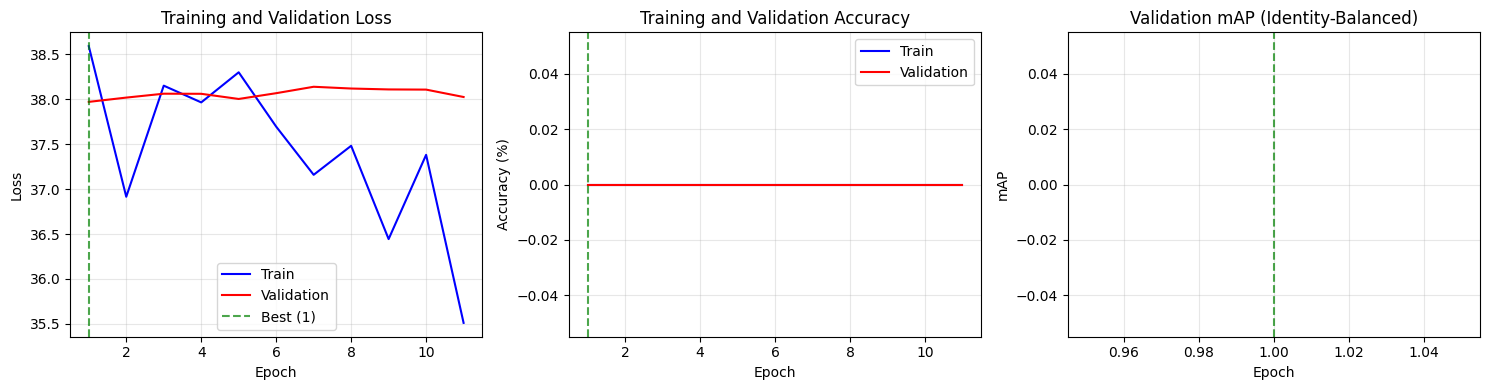

In [27]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Validation')
axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# mAP
axes[2].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
axes[2].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('mAP')
axes[2].set_title('Validation mAP (Identity-Balanced)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config["checkpoint_dir"] / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves": wandb.Image(fig)})

## 9. Visualize Fine-tuned Embeddings

After training, we visualize the fine-tuned embeddings using MDS and compare them to the baseline. We expect to see tighter clusters for each identity after ArcFace training.

In [28]:
# Load best model
checkpoint = torch.load(config["checkpoint_dir"] / "best.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 1
  Val Loss: 37.9720
  Val mAP: nan


In [29]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_train_embeddings).to(device)
    finetuned_train_embeddings = model.get_embeddings(train_tensor).cpu().numpy()

print(f"Fine-tuned embeddings shape: {finetuned_train_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_train_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (15, 256)
Mean L2 norm: 1.0000


/sc/home/linus.loell/jaguar-reid-linus-loell/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/linus.loell/jaguar-reid-linus-loell/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/linus.loell/jaguar-reid-linus-loell/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


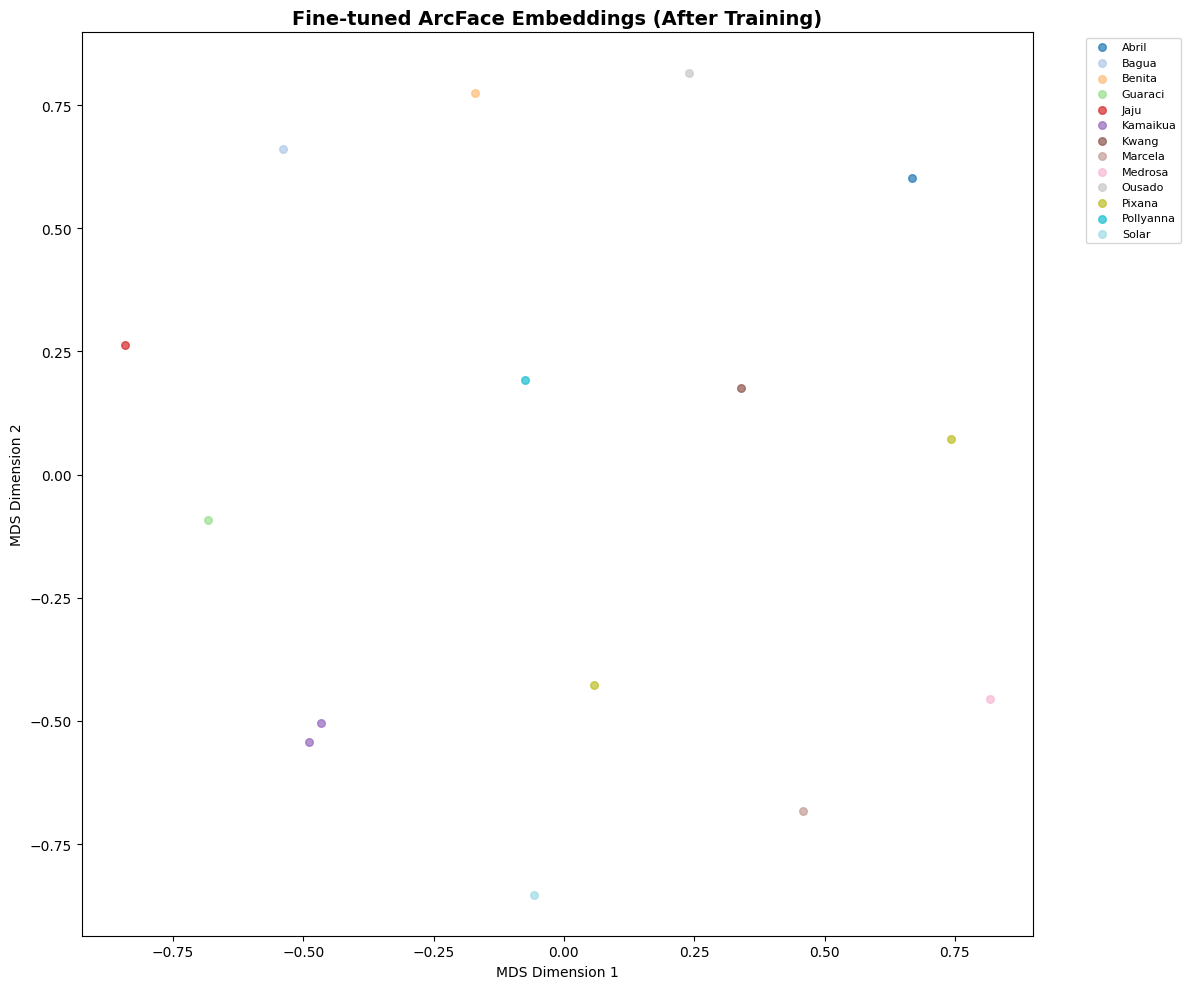

In [30]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_train_embeddings,
    train_labels,
    "Fine-tuned ArcFace Embeddings (After Training)"
)
plt.show()

# Log to W&B
wandb.log({"finetuned_embeddings_mds": wandb.Image(fig_finetuned)})

## 10. Generate Competition Submission

Now we generate predictions for the test set. The competition expects:
- A CSV with columns: `row_id`, `similarity`
- Each row corresponds to a query-gallery image pair from `test.csv`
- `similarity` is a float between 0 and 1

We:
1. Extract Backbone embeddings for all test images
2. Project through our fine-tuned model
3. Compute cosine similarity for each pair in `test.csv`
4. Clip values to [0, 1] and save as CSV

In [ ]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(config["data_dir"] / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


: 

In [ ]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [config["data_dir"] / "test/test" / filename for filename in test_images]

# Extract Backbone embeddings for test images
print(f"\nExtracting Backbone embeddings for test images...")
test_backbone_embeddings = extract_embeddings(
    backbone,
    test_image_paths,
    batch_size=config["batch_size"],
    desc="Test embeddings"
)

print(f"Test Backbone embeddings shape: {test_backbone_embeddings.shape}")

Unique test images: 371

Extracting Backbone embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

In [ ]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_backbone_embeddings).to(device)
    test_finetuned_embeddings = model.get_embeddings(test_tensor).cpu().numpy()

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

Fine-tuned test embeddings shape: (371, 768)
Mean L2 norm: 1.0000


In [ ]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities:   0%|          | 0/137270 [00:00<?, ?it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9935
  Mean: 0.0704
  Std: 0.1325


In [ ]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(config["data_dir"] / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.595052
1       1    0.150857
2       2    0.000000
3       3    0.102370
4       4    0.007396
5       5    0.000000
6       6    0.000000
7       7    0.002345
8       8    0.131352
9       9    0.000000

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [ ]:
# Save submission
submission_path = config["checkpoint_dir"] / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: checkpoints/submission.csv
File size: 1819.6 KB


## 11. Save Artifacts to Weights and Biases

We save the best model checkpoint and this notebook as W&B artifacts for reproducibility.

In [ ]:
# Save model as W&B artifact
model_artifact = wandb.Artifact(
    name="arcface-model",
    type="model",
    description="ArcFace fine-tuned Backbone model for jaguar re-identification"
)
model_artifact.add_file(str(config["checkpoint_dir"] / "best.pth"))
wandb.log_artifact(model_artifact)

print("Model artifact saved to W&B")

Model artifact saved to W&B


In [ ]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description="Competition submission file"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [ ]:
# Finish W&B run
wandb.finish()

print("W&B run completed")

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
num_identities,▁
train_acc,▁▁▁▁▁▂▂▂▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████
train_loss,█▇▇▆▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_samples,▁
val_acc,▁▁▁▁▂▃▃▄▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇███████████
val_loss,█▇▇▆▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_map,▁▁▂▂▃▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
val_samples,▁
best_epoch,50


W&B run completed


## Summary
# TODO: update

This notebook demonstrated a complete pipeline for jaguar re-identification:

1. **Data Preparation**: Loaded training data and created a stratified train/validation split ensuring all identities appear in both sets.

2. **Baseline Embeddings**: Extracted 1536-dimensional embeddings using MegaDescriptor-L-384, a vision transformer pre-trained for wildlife re-identification. #TODO

3. **ArcFace Training**: Fine-tuned embeddings using ArcFace loss, which optimizes angular distances on a hypersphere. This encourages embeddings of the same jaguar to cluster together.

4. **Visualization**: Used MDS to project embeddings to 2D, comparing baseline vs fine-tuned representations.

5. **Submission**: Generated predictions by computing cosine similarity between fine-tuned embeddings for all test pairs.

**Key Hyperparameters**:
- ArcFace margin: 0.5 (adds 28.6 degrees angular penalty)
- ArcFace scale: 64 (controls softmax sharpness)
- Embedding dimension: 256 (projected from 1536)
- Learning rate: 1e-4 with ReduceLROnPlateau scheduler

**Next Steps**:
- Experiment with different margins and scales
- Try data augmentation during training
- Ensemble multiple models
- Fine-tune the backbone (more compute required)